# Assignment 1:
Linear Regression using Deep Neural Network for Boston Housing Price Prediction

In [ ]:
# Install required libraries
!pip install tensorflow scikit-learn pandas matplotlib
import matplotlib.pyplot as plt

In [ ]:
# Step 1: Load the dataset
import pandas as pd

# Load the dataset from a CSV file
df = pd.read_csv('boston_housing.csv')

# Display the first few rows of the dataset
print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  medv  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [ ]:
# Step 2: Preprocess the data

from sklearn.preprocessing import StandardScaler

# Split the data into input and output variables
X = df.drop('medv', axis=1)
Y = df['medv']

# Scale the input features
scaler = StandardScaler()
X = scaler.fit_transform(X)
print(X[:5])

[[-0.34999858  0.26442411 -1.1028962  -0.23739562  0.40593453  0.5863799
  -0.00550898 -0.25677763 -0.7666472  -0.30126622 -1.99947018  0.4793526
  -1.10498659]
 [-0.34367519 -0.44518383 -0.25526642 -0.23739562 -0.63905779  0.30212211
   0.49159069  0.18244087 -0.58160161 -0.76451455 -0.73921026  0.4793526
  -0.42874002]
 [-0.34368121 -0.44518383 -0.25526642 -0.23739562 -0.63905779  1.71233608
  -0.15427603  0.18244087 -0.58160161 -0.76451455 -0.73921026  0.36776728
  -1.2594179 ]
 [-0.34215083 -0.44518383 -1.12604575 -0.23739562 -0.80565077  1.36716591
  -0.70943114  0.73082552 -0.39655601 -0.936088   -0.28551669  0.41711705
  -1.4366075 ]
 [-0.3311007  -0.44518383 -1.12604575 -0.23739562 -0.80565077  1.64219455
  -0.4046401   0.73082552 -0.39655601 -0.936088   -0.28551669  0.4793526
  -1.04809084]]


In [ ]:
# Step 3: Split the dataset

from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

# Print the shapes of the training and testing sets
print('Training set shape:', X_train.shape, y_train.shape)
print('Testing set shape:',  X_test.shape,  y_test.shape)

Training set shape: (354, 13) (354,)
Testing set shape: (152, 13) (152,)


In [ ]:
# Step 4: Define the model architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define the model architecture
model = Sequential()
model.add(Dense(128, input_dim=13, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))

# Display the model summary
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,113 (39.50 KB)

 Trainable params: 10,113 (39.50 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Step 5: Compile the model

model.compile(
    loss='mean_squared_error',
    optimizer='adam',
    metrics=['mean_absolute_error']
)


In [ ]:
# Step 6: Train the model

from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)



Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 564.9144 - mean_absolute_error: 22.0631 - val_loss: 512.3965 - val_mean_absolute_error: 20.5826
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 509.1942 - mean_absolute_error: 20.8672 - val_loss: 461.6631 - val_mean_absolute_error: 19.3608
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 446.0778 - mean_absolute_error: 19.3688 - val_loss: 401.9750 - val_mean_absolute_error: 17.8012
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 369.5637 - mean_absolute_error: 17.4411 - val_loss: 332.2833 - val_mean_absolute_error: 15.7395
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 285.7337 - mean_absolute_error: 14.9664 - val_loss: 257.3495 - val_mean_absolute_error: 13.3049
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 204.3145 - mean_absolute_error: 12.1604 - val_loss: 192.3182 - val_mean_absolute_error: 11.0205
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 143.5881 - mean_abs

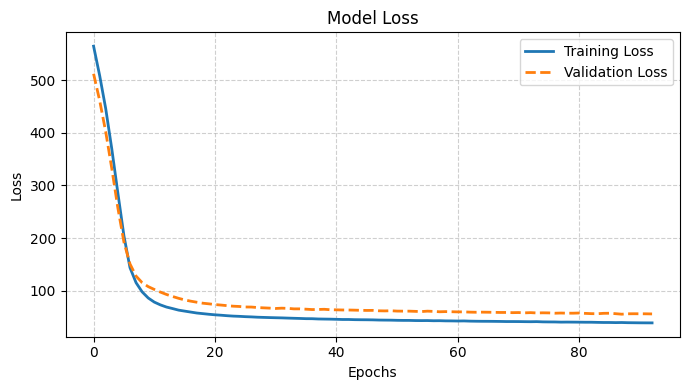

In [ ]:
plt.figure(figsize=(7,4))

plt.plot(history.history['loss'],
         linestyle='-', linewidth=2, label='Training Loss')

plt.plot(history.history['val_loss'],
         linestyle='--', linewidth=2, label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Step 7: Evaluate the model

# Evaluate the model on the testing set
loss, mae = model.evaluate(X_test, y_test)

# Print the mean absolute error
print('Mean Absolute Error:', mae)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 76.6835 - mean_absolute_error: 6.0144 
Mean Absolute Error: 6.014383792877197


In [ ]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
mse_nn, mae_nn= model.evaluate(X_test, y_test)
r2 = r2_score(y_test, y_pred)
print('Mean squared error on test data: ', mse_nn)
print('Mean absolute error on test data: ', mae_nn)
print('Accuracy:', r2*100)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 76.6835 - mean_absolute_error: 6.0144 
Mean squared error on test data:  76.68347930908203
Mean absolute error on test data:  6.014383792877197
Accuracy: 2.3905101783697424


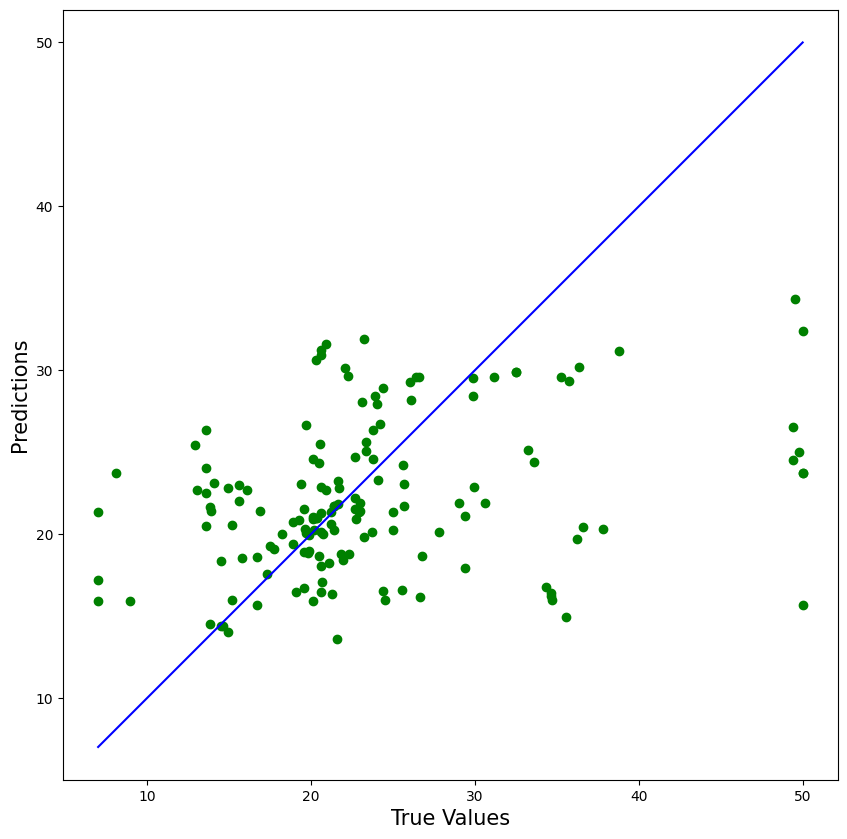

In [ ]:
plt.figure(figsize=(10,10))
plt.scatter(y_test, y_pred, c='green')
p1 = max(max(y_pred), max(y_test))
p2 = min(min(y_pred), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.show()
